In [1]:
#!pip install 'flax==0.7.2' 'jax<=0.4.13' 'ml_dtypes==0.2.0'
#!mamba install cuda-nvcc==11.6.* -c nvidia -y

In [2]:
import os
#os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import joblib
import pickle
from keras.models import model_from_json
import keras
import seaborn as sns
from sklearn.model_selection import train_test_split
import xarray as xr

2025-11-28 01:19:27.802421: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 01:19:27.813100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764292767.826538      70 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764292767.830945      70 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764292767.840856      70 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
A0 = 11.10757377
g, ρ_I, ρ_W = 9769603575225600.0, 9.207917118369125e-19, 1.0282341471330407e-18
rho_ratio =  ρ_W/ ρ_I
C0 = 0.001

In [4]:
def get_phi(h, s):
    p_W = ρ_W * g * np.maximum(0, h - s)
    p_I = ρ_I * g * h
    if p_I == 0:
        return 0
    return np.maximum((1 - p_W / p_I), 0)

In [5]:
def process_csv(filename):
    df = pd.read_csv(filename, index_col=0)
    df = df.sample(frac=1).reset_index(drop=True)
    df['vel_mag'] = np.sqrt(df['x_velocity_initial']**2 + df['y_velocity_initial']**2)
    df['driving_stress'] = df['h'] * 9.8 * df['mag_s']
    df['s/h'] = df['s'] / df['h']
    df['b/h'] = df['b'] / df['h']
    df['mag_s/mag_h'] = df['mag_s'] / df['mag_h']
    df['mag_b/mag_h'] = df['mag_b'] / df['mag_h']
    df['tu1'] = df['driving_stress'] / df['vel_mag']
    df['tu2'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 2))
    df['tu3'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 3))
    df['tu4'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 4))
    df['tu5'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 5))
    df['1/tu1'] = df['vel_mag'] / df['driving_stress']
    df['1/tu2'] = (df['vel_mag'] ** (1 / 2)) / df['driving_stress']
    df['1/tu3'] = (df['vel_mag'] ** (1 / 3)) / df['driving_stress']
    df['1/tu4'] = (df['vel_mag'] ** (1 / 4)) / df['driving_stress']
    df['1/tu5'] = (df['vel_mag'] ** (1 / 5)) / df['driving_stress']
    df['1/tu6'] = (df['vel_mag'] ** (1 / 6)) / df['driving_stress']
    df['invariant1_pow2'] = np.abs(df['invariant1']) ** (1 / 2)
    df['invariant1_pow3'] = np.abs(df['invariant1']) ** (1 / 3)
    df['invariant2_pow2'] = np.abs(df['invariant2']) ** (1 / 2)
    df['invariant2_pow3'] = np.abs(df['invariant2']) ** (1 / 3)
    #df['phi'] = df.apply(lambda row: get_phi(row['h'], row['s']), axis=1)
    #df['C_total'] = C0 * df['phi']*np.exp(df['C'])
    return df

In [6]:
df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r005_geo_12.csv')
df_thwaites = process_csv('regularized_const_01C_C_only_englacial_temp_thwaites_r005_geo_12.csv')
df_dotson = process_csv('regularized_const_01C_C_only_englacial_temp_dotson_r005_geo_12.csv')
df_amundsen = process_csv('regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12.csv')

In [6]:
df_thwaites['boug_anomaly'].min(), df_thwaites['boug_anomaly'].max()

(-12456.842681240509, 17413.200610997108)

In [7]:
df_amundsen['boug_anomaly'].min(), df_amundsen['boug_anomaly'].max()

(-198.3044218800162, 66.06811024778965)

In [8]:
mask = (df_amundsen['mag_anomaly'] > -200)
df_amundsen_2 = df_amundsen[mask].reset_index(drop=True) 

In [9]:
mask = (df_dotson['boug_anomaly'] > -200) & (df_dotson['boug_anomaly'] < 66)
df_dotson_2 = df_dotson[mask].reset_index(drop=True) 

In [10]:
df_thwaites['mag_anomaly'].min(), df_thwaites['mag_anomaly'].max()

(-1163.2700556545965, 917.9602867595172)

In [ ]:
# Assuming df_amundsen is your DataFrame and already defined
sc = plt.scatter(df_amundsen_2['x'], df_amundsen_2['y'], c=df_amundsen_2['boug_anomaly'], s = 0.01)
plt.colorbar(sc, label='mag_anomaly')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot with boug Anomaly')
plt.show()


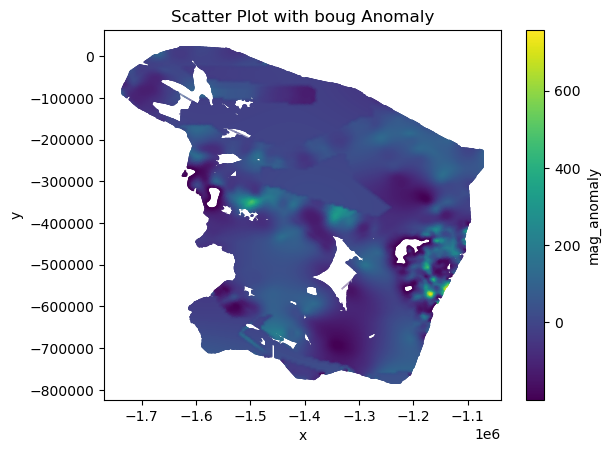

In [13]:
# Assuming df_amundsen is your DataFrame and already defined
sc = plt.scatter(df_amundsen_2['x'], df_amundsen_2['y'], c=df_amundsen_2['mag_anomaly'], s = 0.01)
plt.colorbar(sc, label='mag_anomaly')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot with boug Anomaly')
plt.show()

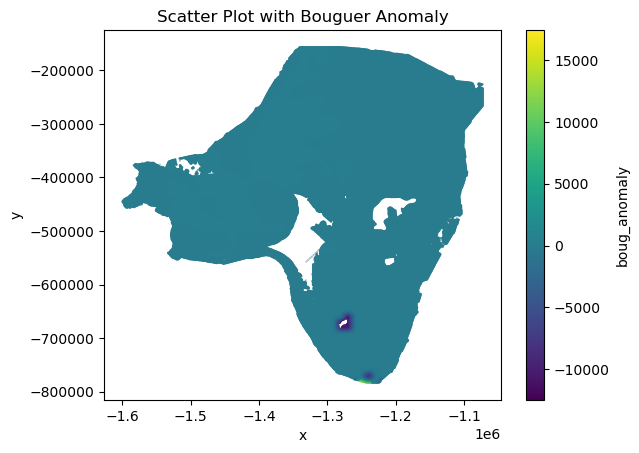

In [9]:
sc = plt.scatter(df_thwaites_2['x'], df_thwaites_2['y'], c=df_thwaites_2['boug_anomaly'], s = 0.01)
plt.colorbar(sc, label='boug_anomaly')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot with Bouguer Anomaly')
plt.show()

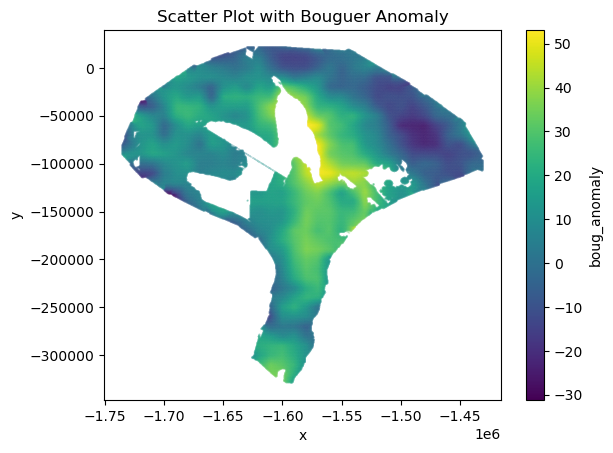

In [25]:
sc = plt.scatter(df_pig['x'], df_pig['y'], c=df_pig['boug_anomaly'], s = 0.01)
plt.colorbar(sc, label='boug_anomaly')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot with Bouguer Anomaly')
plt.show()

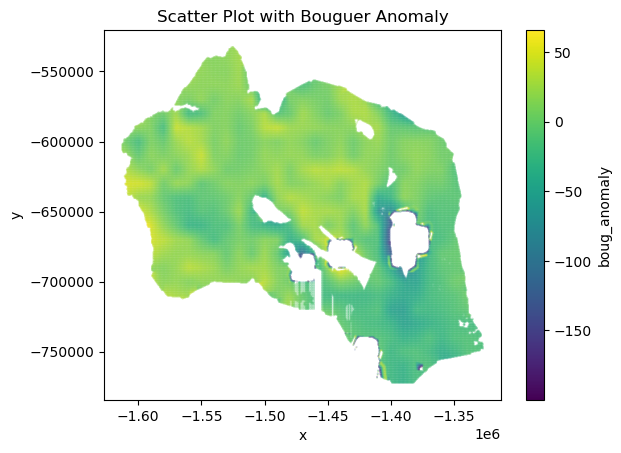

In [28]:
sc = plt.scatter(df_dotson_2['x'], df_dotson_2['y'], c=df_dotson_2['boug_anomaly'], s = 0.01)
plt.colorbar(sc, label='boug_anomaly')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot with Bouguer Anomaly')
plt.show()

In [6]:
df_thwaites['C'].min(), df_thwaites['C'].max(), df_thwaites['theta'].min(), df_thwaites['theta'].max()

(-49.95799638463861, 16.399036573030894, 0.0, 0.0)

In [7]:
df_dotson['C'].min(), df_dotson['C'].max(), df_dotson['theta'].min(), df_dotson['theta'].max()

(-1.7235931138488148, 14.859750559772966, 0.0, 0.0)

In [8]:
df_pig['C'].min(), df_pig['C'].max(), df_pig['theta'].min(), df_pig['theta'].max()

(-10.125017102655573, 43.11043602555095, 0.0, 0.0)

In [9]:
df_dotson['C_total'].min(), df_dotson['C_total'].max()

(0.0, 7.14116044919234)

In [10]:
df_pig['C_total'].min(), df_pig['C_total'].max()

(0.0, 9.55501298722784)

In [11]:
df_thwaites['C_total'].min(), df_thwaites['C_total'].max()

(0.0, 2.807445234432448)

In [9]:
print(df_thwaites['vel_mag'].max(), df_pig['vel_mag'].max(),df_dotson['vel_mag'].max())

4980.435512558016 10854.849828886307 4363.337143233194


In [11]:
df = pd.concat([df_thwaites, df_pig, df_dotson], ignore_index=True)

In [13]:
df_dotson.describe()

,theta,C,C_total,x,y,s11,s12,s21,s22,grad_h_1,...,1/tu1,1/tu2,1/tu3,1/tu4,1/tu5,1/tu6,invariant1_pow2,invariant1_pow3,invariant2_pow2,invariant2_pow3
count,190315.0,190315.000000,190315.000000,1.903150e+05,190315.000000,190315.000000,190315.000000,190315.000000,190315.000000,190315.000000,...,190315.000000,190315.000000,190315.000000,190315.000000,190315.000000,190315.000000,190315.000000,190315.000000,1.903150e+05,190315.000000
mean,0.0,1.699738,0.041245,-1.465446e+06,-649281.451410,0.001037,-0.000004,-0.000836,0.000732,0.008832,...,19.059334,0.957301,0.371963,0.234561,0.178585,0.149163,0.071797,0.161431,1.097023e-02,0.039859
std,0.0,0.977014,0.113694,7.395403e+04,52597.096243,0.020435,0.035207,0.024876,0.024311,0.075868,...,631.792568,54.179905,24.151329,16.159576,12.707803,10.830697,0.060782,0.088330,2.158717e-02,0.044498
min,0.0,-1.723593,0.000000,-1.612675e+06,-772325.000000,-0.542109,-0.789243,-0.682437,-1.094406,-0.895256,...,-40337.651478,-1218.824322,-379.621918,-211.863608,-149.306740,-118.239190,0.000108,0.002263,4.335945e-07,0.000057
25%,0.0,1.450091,0.008783,-1.530775e+06,-689525.000000,-0.001430,-0.003240,-0.002016,-0.001690,-0.018794,...,0.135644,0.029648,0.017187,0.012898,0.010809,0.009594,0.030270,0.097128,1.266618e-03,0.011707
50%,0.0,1.746738,0.031570,-1.461025e+06,-644975.000000,0.000394,-0.000040,0.000069,0.000246,0.006377,...,0.348219,0.052168,0.027993,0.020672,0.017319,0.015431,0.055662,0.145782,4.070739e-03,0.025495
75%,0.0,2.119447,0.049801,-1.400725e+06,-607175.000000,0.003918,0.003670,0.003664,0.003168,0.038018,...,2.648916,0.192058,0.085453,0.058248,0.046567,0.040291,0.095379,0.208754,1.155493e-02,0.051111
max,0.0,14.859751,7.141160,-1.327375e+06,-532475.000000,0.299914,1.494724,0.485695,1.388969,0.973338,...,265701.272716,22833.830002,10076.440380,6693.778353,5237.087627,4446.676301,1.033781,1.022396,1.035138e+00,1.023291


In [14]:
df_thwaites.describe()

,theta,C,C_total,x,y,s11,s12,s21,s22,grad_h_1,...,1/tu1,1/tu2,1/tu3,1/tu4,1/tu5,1/tu6,invariant1_pow2,invariant1_pow3,invariant2_pow2,invariant2_pow3
count,853332.0,853332.000000,853332.000000,8.533320e+05,853332.000000,853332.000000,853332.000000,853332.000000,853332.000000,853332.000000,...,853332.000000,853332.000000,853332.000000,853332.000000,853332.000000,853332.000000,853332.000000,853332.000000,8.533320e+05,853332.000000
mean,0.0,1.335180,0.023374,-1.289763e+06,-428336.696327,0.001205,0.000418,0.000260,0.000302,0.003552,...,1.901634,0.118622,0.054579,0.038194,0.031142,0.027293,0.036346,0.100202,3.066689e-03,0.014940
std,0.0,0.675162,0.025171,1.139519e+05,146599.669210,0.011105,0.017626,0.011366,0.010368,0.065545,...,20.156861,0.654897,0.235447,0.145178,0.109852,0.091720,0.042445,0.067020,1.128884e-02,0.025487
min,0.0,-49.957996,0.000000,-1.600075e+06,-783575.000000,-0.444544,-0.645963,-0.418945,-0.699046,-1.505323,...,-5534.928456,-91.425604,-27.454366,-21.669068,-18.800852,-17.102873,0.000019,0.000721,1.945227e-07,0.000034
25%,0.0,1.000635,0.012204,-1.365625e+06,-526625.000000,-0.000328,-0.000370,-0.000584,-0.000326,-0.018345,...,0.081394,0.026141,0.017129,0.013585,0.011728,0.010597,0.014461,0.059355,2.746811e-04,0.004226
50%,0.0,1.424838,0.021377,-1.273375e+06,-419525.000000,0.000078,0.000080,-0.000007,0.000084,0.004151,...,0.224229,0.047139,0.027464,0.020888,0.017751,0.015946,0.023915,0.083007,6.503435e-04,0.007506
75%,0.0,1.734914,0.031665,-1.203175e+06,-315125.000000,0.000762,0.000842,0.000517,0.000561,0.024738,...,0.832724,0.095243,0.048259,0.035176,0.029392,0.026176,0.041394,0.119662,1.821098e-03,0.014913
max,0.0,16.399037,2.807445,-1.072675e+06,-156275.000000,0.766943,0.800556,1.014980,0.435299,1.139096,...,5135.032230,199.877172,75.667215,46.556468,34.787514,28.645229,0.808237,0.867679,6.463729e-01,0.747576


In [15]:
df_pig.describe()

,theta,C,C_total,x,y,s11,s12,s21,s22,grad_h_1,...,1/tu1,1/tu2,1/tu3,1/tu4,1/tu5,1/tu6,invariant1_pow2,invariant1_pow3,invariant2_pow2,invariant2_pow3
count,207050.0,207050.000000,207050.000000,2.070500e+05,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000,...,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000,207050.000000
mean,0.0,0.704253,0.020127,-1.586142e+06,-98663.983096,-0.000621,0.001948,0.001654,0.002021,0.001631,...,22.426257,0.524340,0.167831,0.098118,0.071960,0.058832,0.061196,0.141315,0.012889,0.039134
std,0.0,1.588513,0.137703,6.945513e+04,78953.490064,0.038290,0.030330,0.087055,0.035930,0.051459,...,204.810922,3.535719,0.935257,0.487097,0.331659,0.257736,0.071674,0.096329,0.036419,0.062086
min,0.0,-10.125017,0.000000,-1.735525e+06,-329075.000000,-3.058761,-2.550016,-1.592964,-1.343592,-1.348768,...,-738.342019,-108.192731,-57.039833,-41.416017,-34.179238,-30.071730,0.000067,0.001644,0.000002,0.000150
25%,0.0,0.457628,0.005473,-1.635175e+06,-140525.000000,-0.001636,-0.001431,-0.001616,-0.000607,-0.011256,...,0.321693,0.052891,0.028995,0.021232,0.017485,0.015313,0.023573,0.082214,0.000838,0.008890
50%,0.0,1.019542,0.014504,-1.584775e+06,-84275.000000,0.000041,0.000202,0.000150,0.000521,0.003296,...,0.778092,0.096367,0.048580,0.034682,0.028377,0.024877,0.038824,0.114656,0.002012,0.015939
75%,0.0,1.440971,0.022058,-1.538425e+06,-39275.000000,0.001410,0.002404,0.001458,0.002561,0.017194,...,4.212752,0.262117,0.108011,0.070836,0.055355,0.047144,0.068417,0.167279,0.008071,0.040235
max,0.0,43.110436,9.555013,-1.430425e+06,21925.000000,0.729263,1.048056,4.355744,2.496305,0.774137,...,56031.424226,911.051161,230.805667,116.171158,76.950143,58.472299,1.198179,1.128100,2.461295,1.822954


In [16]:
np.median(df_pig['C_total']), np.median(df_dotson['C_total']), np.median(df_thwaites['C_total'])

(0.014503798800130849, 0.0315696858345562, 0.02137664673832165)

In [17]:
np.isnan(df_pig['C_total']).any(), np.isnan(df_dotson['C_total']).any(),np.isnan(df_thwaites['C_total']).any()

(False, False, False)

In [18]:
np.isnan(df_pig['C']).any(), np.isnan(df_dotson['C']).any(),np.isnan(df_thwaites['C']).any()

(False, False, False)

In [19]:
(df_pig['h'] == 0).any(), (df_dotson['h'] == 0).any(),(df_dotson['h'] == 0).any() 

(False, False, False)

In [20]:
0.01*np.exp(1.33)

0.03781043387568781

In [21]:
0.01*np.exp(0.71)

0.020339912586467505

In [6]:
# List of columns to plot
# columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'invariant1', 'invariant2', 'tu1','tu2','tu3','tu4','tu5','invariant1_pow2','invariant1_pow3','invariant2_pow2','invariant2_pow3'] 
# columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'invariant1', 'invariant2', 'invariant1_pow2','invariant1_pow3','invariant2_pow2','invariant2_pow3'] 
# columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'invariant1', 'invariant2', '1/tu1','1/tu2','1/tu3','1/tu4','1/tu5','1/tu6','invariant1_pow2','invariant1_pow3','invariant2_pow2','invariant2_pow3'] 

columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'heatflux', 'surface_air_temp','gravity_disturbance', 'mag_anomaly']
# columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'invariant1', 'invariant2', 'tu1','tu2', 'tu3', 'tu4', 'tu5']
# columns = ['s/h', 'b/h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress']  
# columns = ['s/h', 'b/h', 'mag_s/mag_h','mag_b/mag_h' ]

In [23]:
len(columns)

11

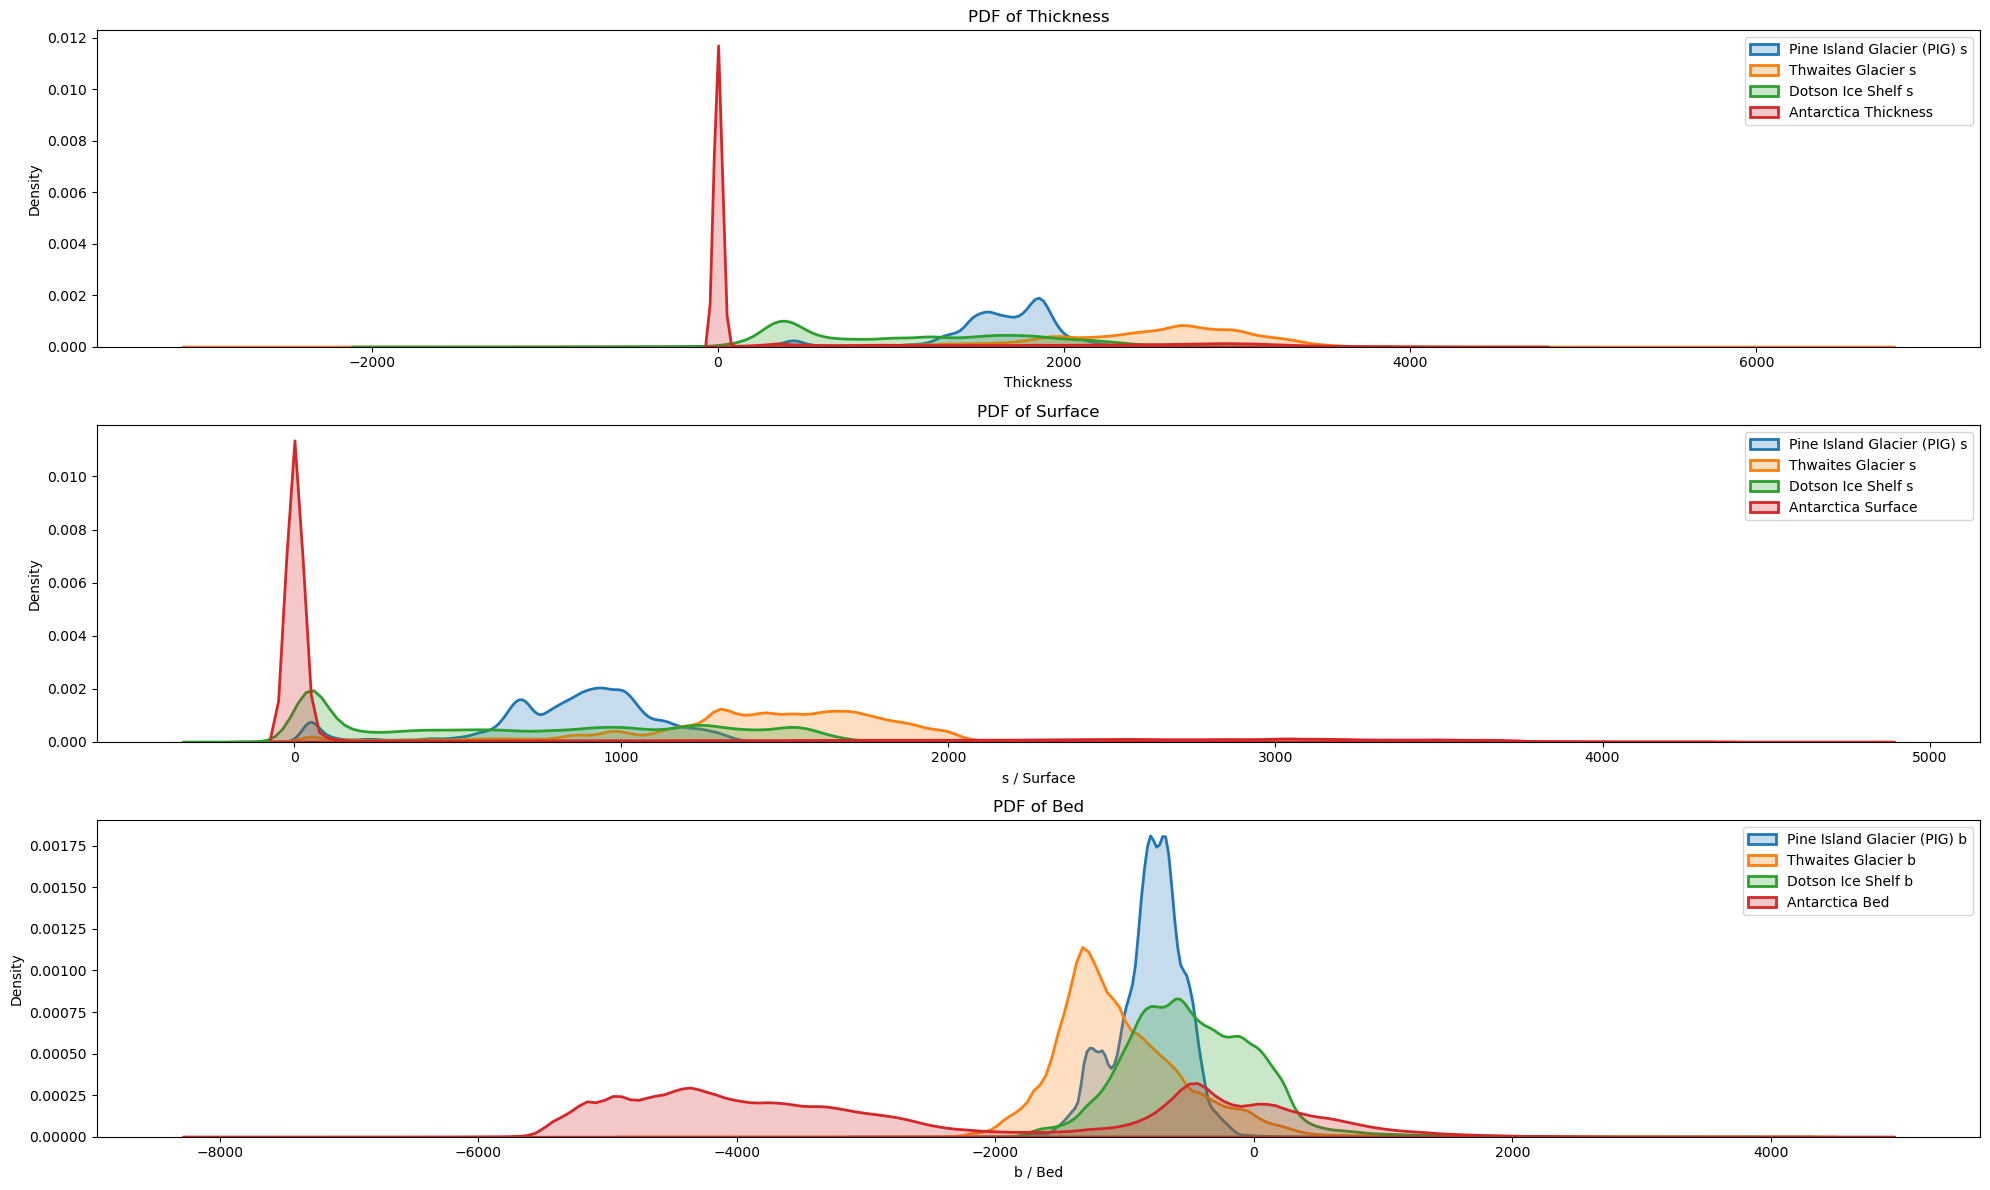

In [26]:
# Extract the thickness, surface and bed data
thickness = antarctica['thickness'].values
surface = antarctica['surface'].values
bed = antarctica['bed'].values

# Extract the relevant columns from the dataframes
h_pig = df_pig['h']
h_thwaites = df_thwaites['h']
h_dotson = df_dotson['h']
s_pig = df_pig['s']
s_thwaites = df_thwaites['s']
s_dotson = df_dotson['s']
b_pig = df_pig['b']
b_thwaites = df_thwaites['b']
b_dotson = df_dotson['b']

# Extract surface and bed data from the xarray dataset
surface = antarctica['surface'].values
bed = antarctica['bed'].values

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(20, 12))

# Subplot 1: PDF for thickness
sns.kdeplot(h_pig, label='Pine Island Glacier (PIG) s', linewidth=2, ax=axes[0], fill=True)
sns.kdeplot(h_thwaites, label='Thwaites Glacier s', linewidth=2, ax=axes[0], fill=True)
sns.kdeplot(h_dotson, label='Dotson Ice Shelf s', linewidth=2, ax=axes[0], fill=True)
sns.kdeplot(thickness.flatten(), label='Antarctica Thickness', linewidth=2, ax=axes[0], fill=True)
axes[0].set_xlabel('Thickness')
axes[0].set_ylabel('Density')
axes[0].set_title('PDF of Thickness')
axes[0].legend()

# Subplot 2: PDF for s (dataframes) and surface (xarray)
sns.kdeplot(s_pig, label='Pine Island Glacier (PIG) s', linewidth=2, ax=axes[1], fill=True)
sns.kdeplot(s_thwaites, label='Thwaites Glacier s', linewidth=2, ax=axes[1], fill=True)
sns.kdeplot(s_dotson, label='Dotson Ice Shelf s', linewidth=2, ax=axes[1], fill=True)
sns.kdeplot(surface.flatten(), label='Antarctica Surface', linewidth=2, ax=axes[1], fill=True)
axes[1].set_xlabel('s / Surface')
axes[1].set_ylabel('Density')
axes[1].set_title('PDF of Surface')
axes[1].legend()

# Subplot 3: PDF for b (dataframes) and bed (xarray)
sns.kdeplot(b_pig, label='Pine Island Glacier (PIG) b', linewidth=2, ax=axes[2], fill=True)
sns.kdeplot(b_thwaites, label='Thwaites Glacier b', linewidth=2, ax=axes[2], fill=True)
sns.kdeplot(b_dotson, label='Dotson Ice Shelf b', linewidth=2, ax=axes[2], fill=True)
sns.kdeplot(bed.flatten(), label='Antarctica Bed', linewidth=2, ax=axes[2], fill=True)
axes[2].set_xlabel('b / Bed')
axes[2].set_ylabel('Density')
axes[2].set_title('PDF of Bed')
axes[2].legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

CLASSIFICATION RESULTS
Total Amundsen points: 1530051
Classified as PIG: 214337 (14.0%)
Classified as Thwaites: 861100 (56.3%)
Classified as Dotson: 194873 (12.7%)
Between PIG-Thwaites: 246878 (16.1%)
Between Thwaites-Dotson: 12863 (0.8%)
Total classified: 1530051


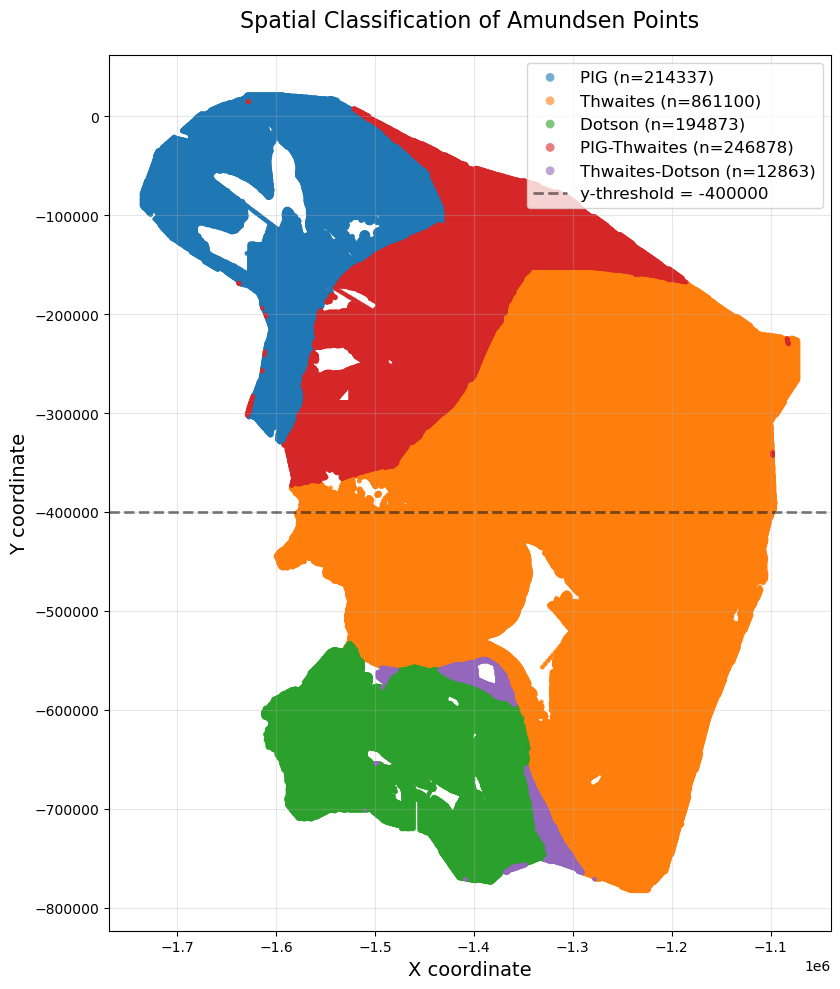


Spatial plot saved as 'amundsen_spatial_classification.png'


In [21]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create labeled coordinates from known glaciers
pig_coords = df_pig[['x', 'y']].copy()
pig_coords['label'] = 'PIG'

thwaites_coords = df_thwaites[['x', 'y']].copy()
thwaites_coords['label'] = 'Thwaites'

dotson_coords = df_dotson[['x', 'y']].copy()
dotson_coords['label'] = 'Dotson'

# Combine all three
glacier_coords = pd.concat([pig_coords, thwaites_coords, dotson_coords], ignore_index=True)

# Step 2: Build KDTree from known glacier points
known_points = glacier_coords[['x', 'y']].values
known_labels = glacier_coords['label'].values

tree = KDTree(known_points)

# Step 3: Query Amundsen points - find nearest neighbor
amundsen_points = df_amundsen[['x', 'y']].values
distances, indices = tree.query(amundsen_points, k=1)

# Get the nearest glacier label for each Amundsen point
nearest_glacier = known_labels[indices]
df_amundsen['nearest_glacier'] = nearest_glacier
df_amundsen['distance_to_nearest'] = distances

# Step 4: Identify glacier core points (those very close to known glacier points)
# Use a small distance threshold - only points essentially AT the glacier locations
distance_threshold = 3000  # meters - adjust based on your coordinate units
df_amundsen['is_glacier_core'] = df_amundsen['distance_to_nearest'] < distance_threshold

# Step 5: Extract the three glacier regions
df_amundsen_pig = df_amundsen[(df_amundsen['is_glacier_core']) & 
                               (df_amundsen['nearest_glacier'] == 'PIG')].copy()
df_amundsen_thwaites = df_amundsen[(df_amundsen['is_glacier_core']) & 
                                    (df_amundsen['nearest_glacier'] == 'Thwaites')].copy()
df_amundsen_dotson = df_amundsen[(df_amundsen['is_glacier_core']) & 
                                  (df_amundsen['nearest_glacier'] == 'Dotson')].copy()

# Step 6: Get the remaining points (not in glacier cores)
df_remaining = df_amundsen[~df_amundsen['is_glacier_core']].copy()

# Step 7: Split remaining points by y-coordinate
y_threshold = -400000

df_between_pig_thwaites = df_remaining[df_remaining['y'] >= y_threshold].copy()
df_between_thwaites_dotson = df_remaining[df_remaining['y'] < y_threshold].copy()

# Add labels for visualization
df_amundsen_pig['region_label'] = 'PIG'
df_amundsen_thwaites['region_label'] = 'Thwaites'
df_amundsen_dotson['region_label'] = 'Dotson'
df_between_pig_thwaites['region_label'] = 'PIG-Thwaites'
df_between_thwaites_dotson['region_label'] = 'Thwaites-Dotson'

# Combine all for easy plotting
df_amundsen_classified = pd.concat([
    df_amundsen_pig, 
    df_amundsen_thwaites, 
    df_amundsen_dotson,
    df_between_pig_thwaites,
    df_between_thwaites_dotson
], ignore_index=True)

# Print statistics
print("=" * 70)
print("CLASSIFICATION RESULTS")
print("=" * 70)
print(f"Total Amundsen points: {len(df_amundsen)}")
print(f"Classified as PIG: {len(df_amundsen_pig)} ({100*len(df_amundsen_pig)/len(df_amundsen):.1f}%)")
print(f"Classified as Thwaites: {len(df_amundsen_thwaites)} ({100*len(df_amundsen_thwaites)/len(df_amundsen):.1f}%)")
print(f"Classified as Dotson: {len(df_amundsen_dotson)} ({100*len(df_amundsen_dotson)/len(df_amundsen):.1f}%)")
print(f"Between PIG-Thwaites: {len(df_between_pig_thwaites)} ({100*len(df_between_pig_thwaites)/len(df_amundsen):.1f}%)")
print(f"Between Thwaites-Dotson: {len(df_between_thwaites_dotson)} ({100*len(df_between_thwaites_dotson)/len(df_amundsen):.1f}%)")
print(f"Total classified: {len(df_amundsen_classified)}")
print("=" * 70)

# Step 8: Visualize the spatial distribution
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Define colors for each region
colors = {
    'PIG': '#1f77b4',           # blue
    'Thwaites': '#ff7f0e',      # orange
    'Dotson': '#2ca02c',        # green
    'PIG-Thwaites': '#d62728',  # red
    'Thwaites-Dotson': '#9467bd' # purple
}

# Plot each region with different colors
for region_name, color in colors.items():
    df_region = df_amundsen_classified[df_amundsen_classified['region_label'] == region_name]
    if len(df_region) > 0:
        ax.scatter(df_region['x'], df_region['y'], 
                  c=color, label=f"{region_name} (n={len(df_region)})", 
                  s=10, alpha=0.6, edgecolors='none')

# Add horizontal line showing the y-threshold
ax.axhline(y=y_threshold, color='black', linestyle='--', linewidth=2, 
           label=f'y-threshold = {y_threshold}', alpha=0.5)

ax.set_xlabel('X coordinate', fontsize=14)
ax.set_ylabel('Y coordinate', fontsize=14)
ax.set_title('Spatial Classification of Amundsen Points', fontsize=16, pad=20)
ax.legend(loc='best', fontsize=12, markerscale=2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('amundsen_spatial_classification.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSpatial plot saved as 'amundsen_spatial_classification.png'")


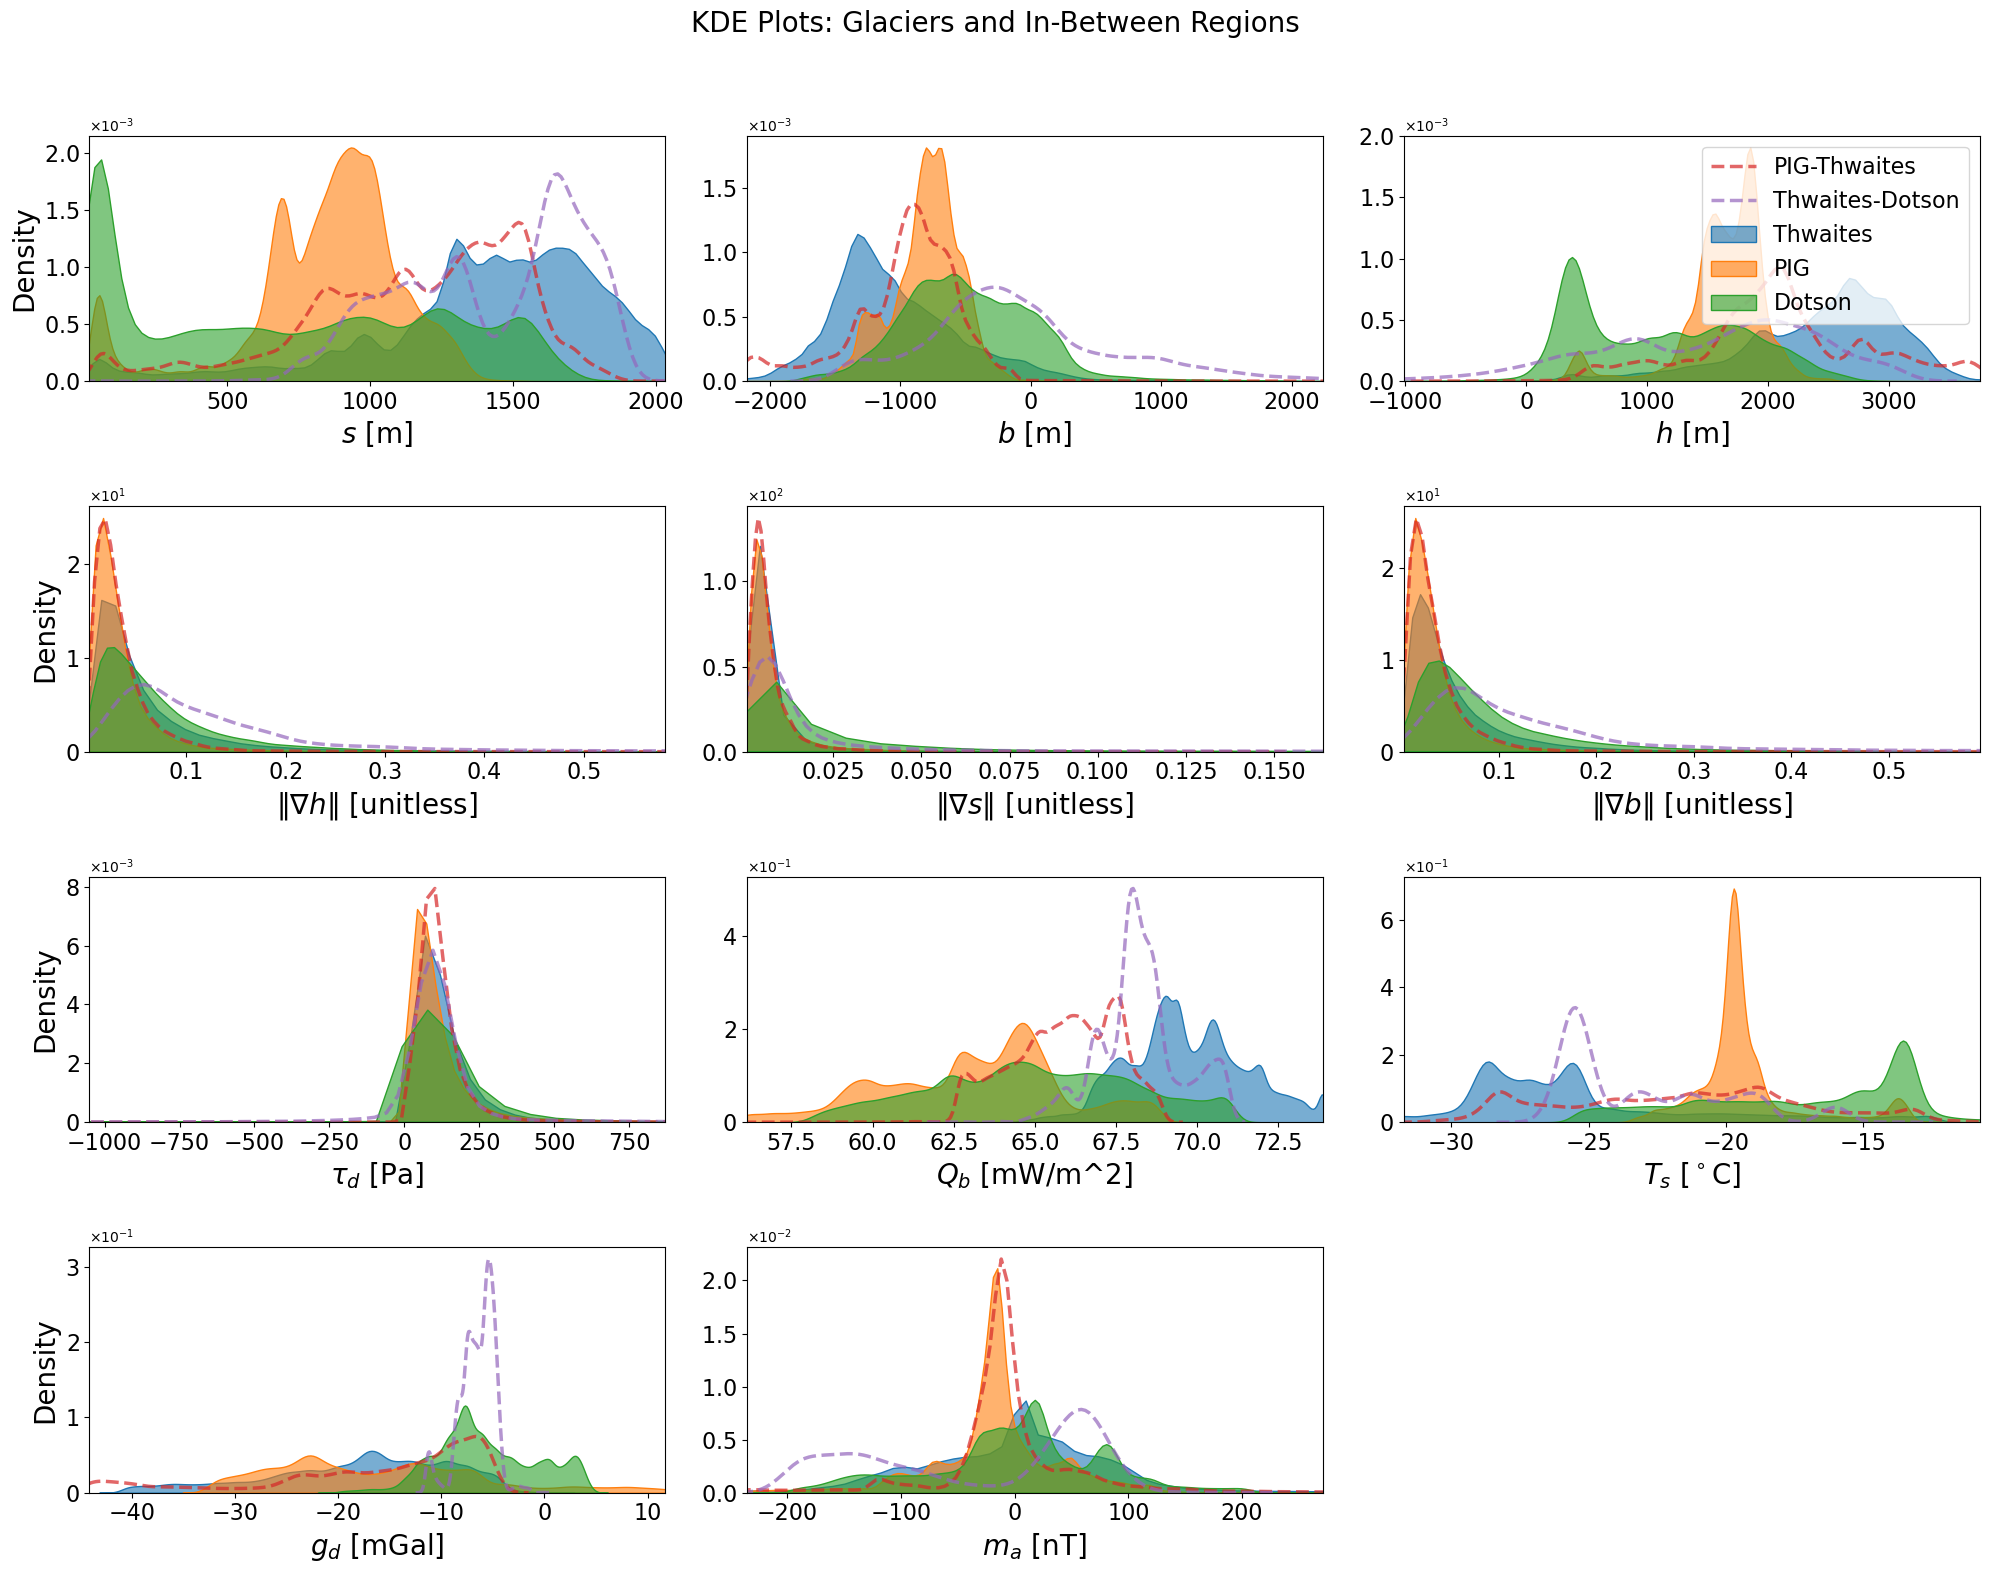

Feature distribution plot saved as 'feature_distribution_with_inbetween.png'


In [22]:
from matplotlib.ticker import ScalarFormatter

FEATURE_SYMBOLS = {
    "s": r"$s$ [m]",
    "b": r"$b$ [m]",
    "h": r"$h$ [m]",
    "mag_s": r"$\|\nabla s\|$ [unitless]",
    "mag_b": r"$\|\nabla b\|$ [unitless]",
    "mag_h": r"$\|\nabla h\|$ [unitless]",
    "driving_stress": r"$\tau_d$ [Pa]",
    "gravity_disturbance": r"$g_d$ [mGal]",
    "heatflux": r"$Q_b$ [mW/m^2]",
    "surface_air_temp": r"$T_s$ [$^\circ$C]",
    "snow_accumulation": r"$A_s$ [mm~w.e./yr]",
    "mag_anomaly": r"$m_a$ [nT]",
}
columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'heatflux', 'surface_air_temp','gravity_disturbance', 'mag_anomaly']

# Percentiles
low_per = 1
max_per = 99

# Calculate number of rows and columns for the subplots
num_cols = 3
num_rows = int(np.ceil(len(columns) / num_cols))

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for i, column in enumerate(columns):
    ax = axes[i]
    
    # Calculate percentiles for all datasets
    thwaites_per = np.percentile(df_thwaites[column].dropna(), [low_per, max_per]) if not df_thwaites[column].isnull().all() else (None, None)
    pig_per = np.percentile(df_pig[column].dropna(), [low_per, max_per]) if not df_pig[column].isnull().all() else (None, None)
    dotson_per = np.percentile(df_dotson[column].dropna(), [low_per, max_per]) if not df_dotson[column].isnull().all() else (None, None)
    pig_thwaites_per = np.percentile(df_between_pig_thwaites[column].dropna(), [low_per, max_per]) if not df_between_pig_thwaites[column].isnull().all() else (None, None)
    thwaites_dotson_per = np.percentile(df_between_thwaites_dotson[column].dropna(), [low_per, max_per]) if not df_between_thwaites_dotson[column].isnull().all() else (None, None)

    # Determine the combined x-axis limits
    x_min = min(p for p in [thwaites_per[0], pig_per[0], dotson_per[0], pig_thwaites_per[0], thwaites_dotson_per[0]] if p is not None)
    x_max = max(p for p in [thwaites_per[1], pig_per[1], dotson_per[1], pig_thwaites_per[1], thwaites_dotson_per[1]] if p is not None)

    # Plot in-between regions first (dashed lines, no fill) so they stay behind
    if not df_between_pig_thwaites[column].isnull().all():
        sns.kdeplot(df_between_pig_thwaites[column], ax=ax, linestyle='--', color='#d62728', 
                   label='PIG-Thwaites', linewidth=2.5, alpha=0.7)
    
    if not df_between_thwaites_dotson[column].isnull().all():
        sns.kdeplot(df_between_thwaites_dotson[column], ax=ax, linestyle='--', color='#9467bd', 
                   label='Thwaites-Dotson', linewidth=2.5, alpha=0.7)

    # Plot glaciers (with fill) on top
    if not df_thwaites[column].isnull().all():
        sns.kdeplot(df_thwaites[column], fill=True, label='Thwaites', ax=ax, alpha=0.6)
    if not df_pig[column].isnull().all():
        sns.kdeplot(df_pig[column], fill=True, label='PIG', ax=ax, alpha=0.6)
    if not df_dotson[column].isnull().all():
        sns.kdeplot(df_dotson[column], fill=True, label='Dotson', ax=ax, alpha=0.6)

    # Set xlabel using symbols
    ax.set_xlabel(FEATURE_SYMBOLS.get(column, column), fontsize=20)

    # Set ylabel only for the first column
    if i % num_cols == 0:
        ax.set_ylabel('Density', fontsize=20)
    else:
        ax.set_ylabel(None)

    # Add legend to top-right subplot
    if i == num_cols - 1:
        ax.legend(loc='upper right', fontsize=16)

    # Set x-axis limits
    ax.set_xlim(x_min, x_max)

    # Format ticks
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.tick_params(axis='both', labelsize=16)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Remove empty subplots
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])

# Super title
plt.suptitle("KDE Plots: Glaciers and In-Between Regions", fontsize=20)

# Tight layout and spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.51)

# Save figure
plt.savefig('feature_distribution_with_inbetween.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature distribution plot saved as 'feature_distribution_with_inbetween.png'")


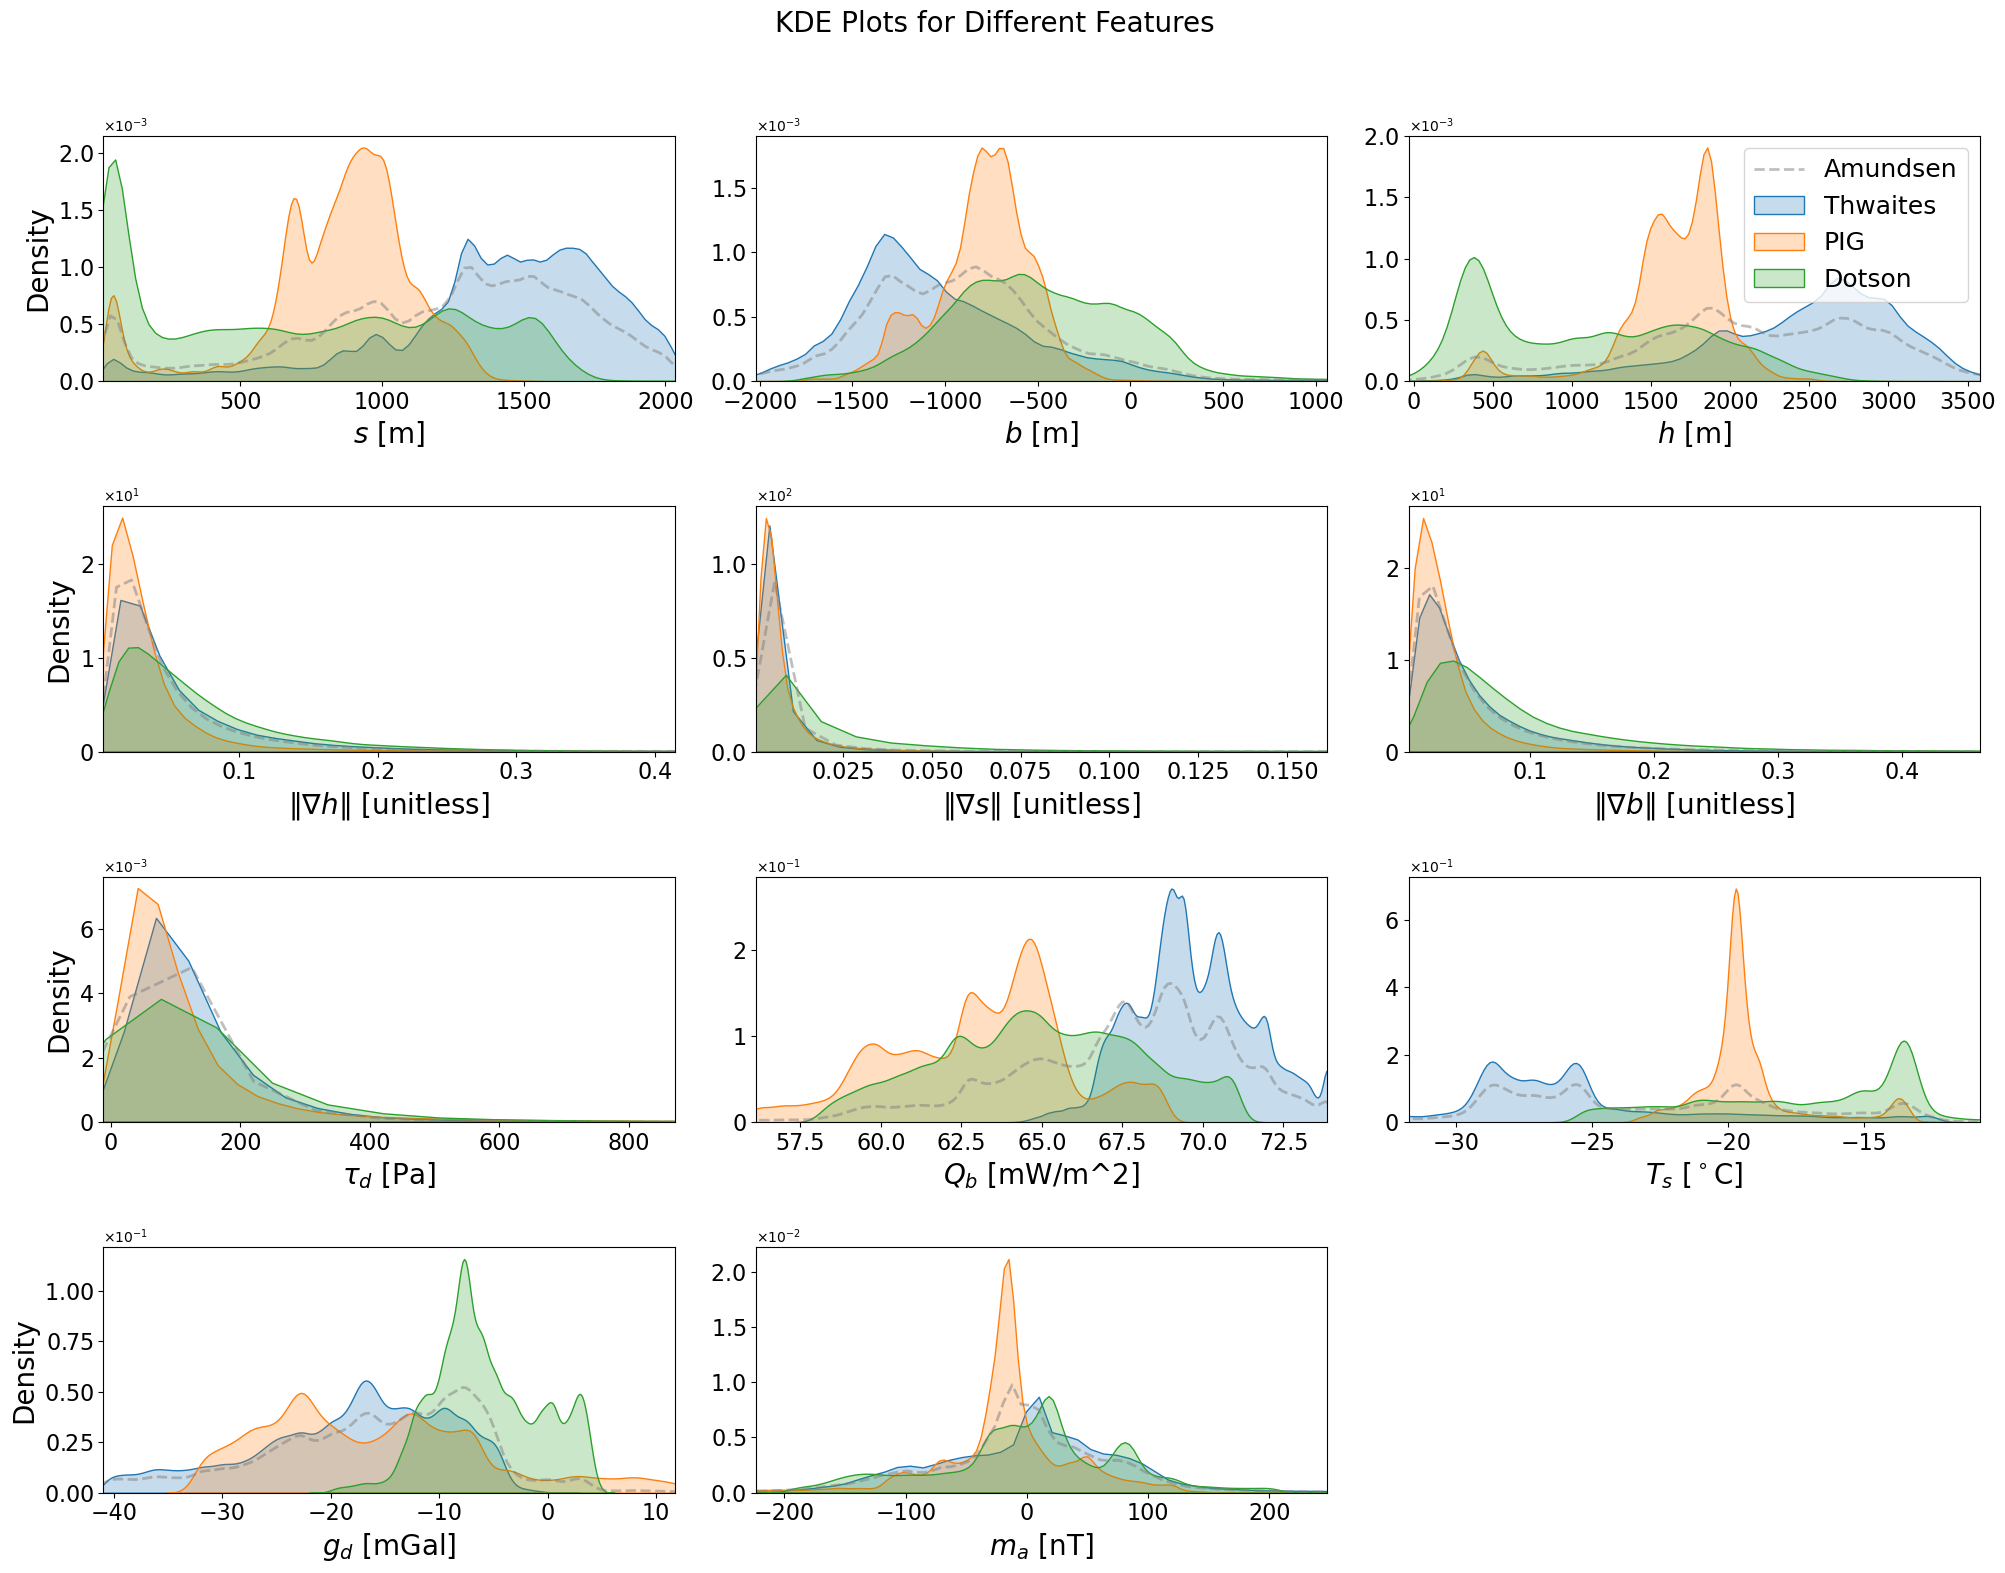

In [23]:
from matplotlib.ticker import ScalarFormatter

FEATURE_SYMBOLS = {
    "s": r"$s$ [m]",
    "b": r"$b$ [m]",
    "h": r"$h$ [m]",
    "mag_s": r"$\|\nabla s\|$ [unitless]",
    "mag_b": r"$\|\nabla b\|$ [unitless]",
    "mag_h": r"$\|\nabla h\|$ [unitless]",
    "driving_stress": r"$\tau_d$ [Pa]",
    "gravity_disturbance": r"$g_d$ [mGal]",
    "heatflux": r"$Q_b$ [mW/m^2]",
    "surface_air_temp": r"$T_s$ [$^\circ$C]",
    "snow_accumulation": r"$A_s$ [mm~w.e./yr]",
    "mag_anomaly": r"$m_a$ [nT]",
}
columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'heatflux', 'surface_air_temp','gravity_disturbance', 'mag_anomaly']


# Percentiles
low_per = 1
max_per = 99

# Calculate number of rows and columns for the subplots
num_cols = 3
num_rows = int(np.ceil(len(columns) / num_cols))

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for i, column in enumerate(columns):
    ax = axes[i]
    
    # Calculate percentiles for all datasets
    thwaites_per = np.percentile(df_thwaites[column].dropna(), [low_per, max_per]) if not df_thwaites[column].isnull().all() else (None, None)
    pig_per = np.percentile(df_pig[column].dropna(), [low_per, max_per]) if not df_pig[column].isnull().all() else (None, None)
    dotson_per = np.percentile(df_dotson[column].dropna(), [low_per, max_per]) if not df_dotson[column].isnull().all() else (None, None)
    amundsen_per = np.percentile(df_amundsen[column].dropna(), [low_per, max_per]) if not df_amundsen[column].isnull().all() else (None, None)

    # Determine the combined x-axis limits
    x_min = min(p for p in [thwaites_per[0], pig_per[0], dotson_per[0], amundsen_per[0]] if p is not None)
    x_max = max(p for p in [thwaites_per[1], pig_per[1], dotson_per[1], amundsen_per[1]] if p is not None)

    # Plot Amundsen first so it stays behind others
    if not df_amundsen[column].isnull().all():
        sns.kdeplot(df_amundsen[column], ax=ax, linestyle='--', color='gray', label='Amundsen', linewidth=2, alpha=0.5)

    # Plot for other glaciers (with fill)
    if not df_thwaites[column].isnull().all():
        sns.kdeplot(df_thwaites[column], fill=True, label='Thwaites', ax=ax)
    if not df_pig[column].isnull().all():
        sns.kdeplot(df_pig[column], fill=True, label='PIG', ax=ax)
    if not df_dotson[column].isnull().all():
        sns.kdeplot(df_dotson[column], fill=True, label='Dotson', ax=ax)

    # Set xlabel using symbols
    ax.set_xlabel(FEATURE_SYMBOLS.get(column, column), fontsize=20)

    # Set ylabel only for the first column
    if i % num_cols == 0:
        ax.set_ylabel('Density', fontsize=20)
    else:
        ax.set_ylabel(None)

    # Add legend to top-right subplot
    if i == num_cols - 1:
        ax.legend(loc='upper right', fontsize=18)

    # Set x-axis limits
    ax.set_xlim(x_min, x_max)

    # Format ticks
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.tick_params(axis='both', labelsize=16)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Remove empty subplots
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])

# Super title
plt.suptitle("KDE Plots for Different Features", fontsize=20)

# Tight layout and spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.51)

# Save figure
plt.savefig('feature_distribution.png')


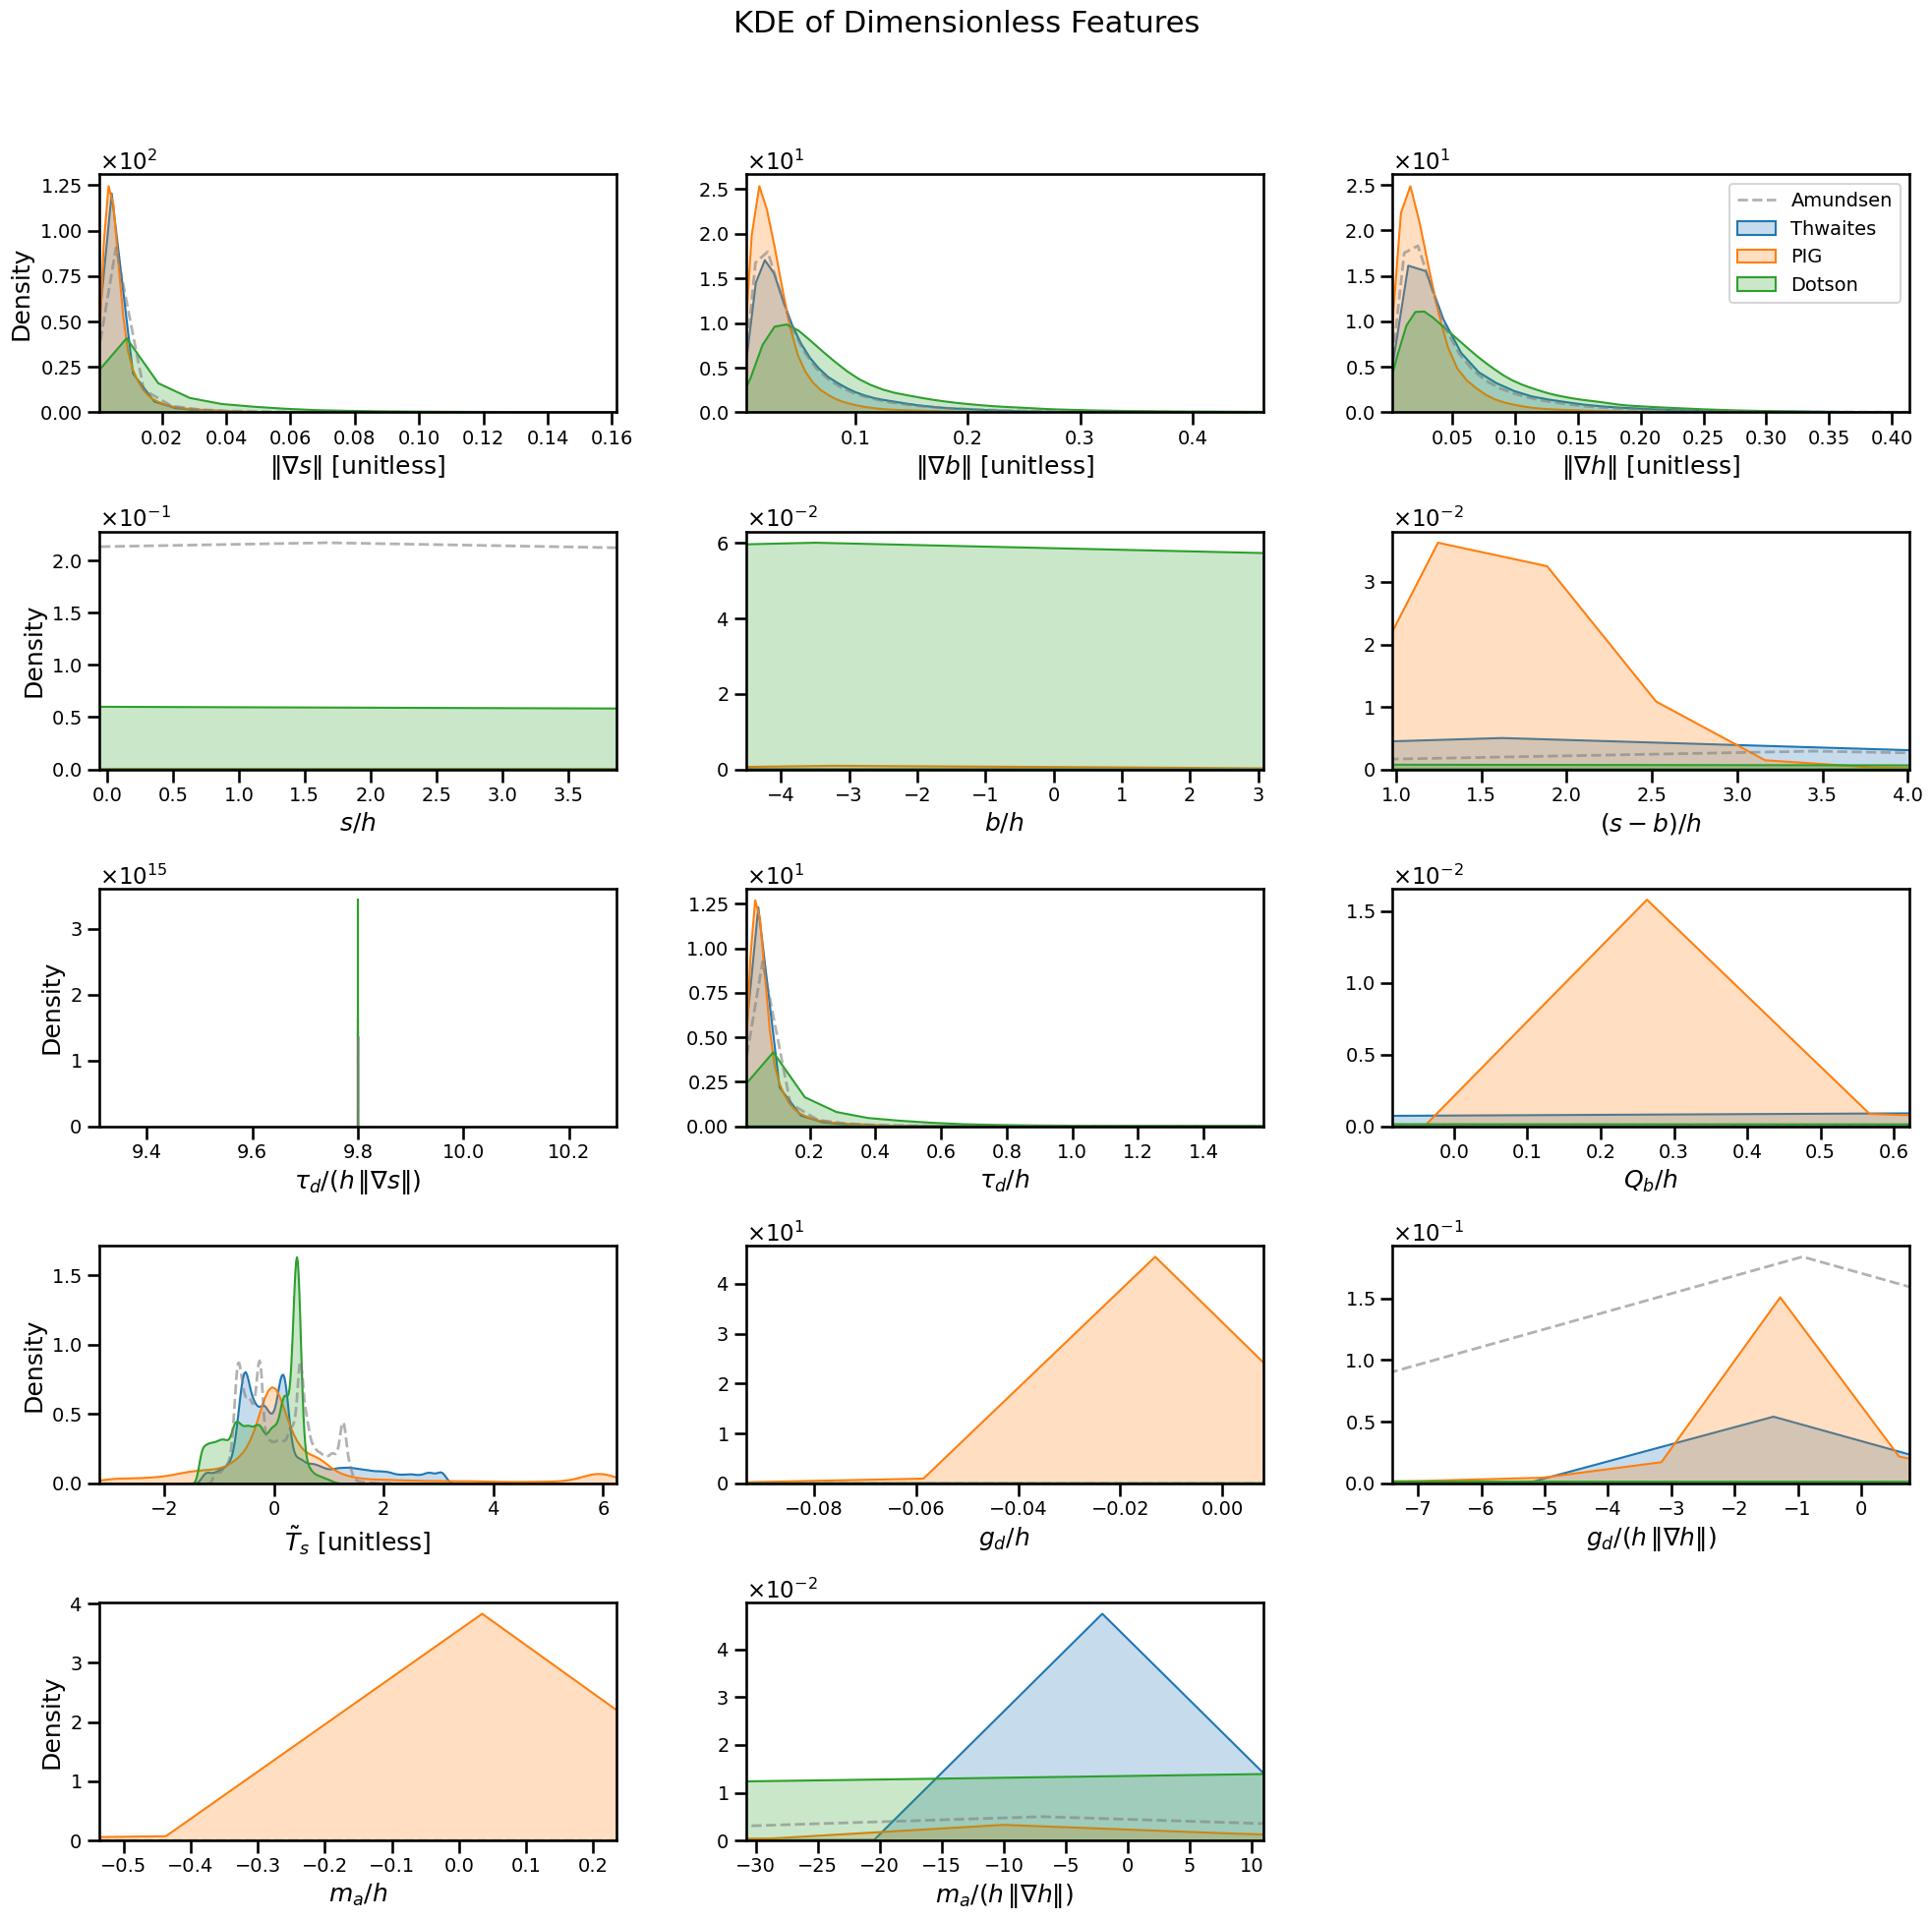

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

FEATURE_SYMBOLS = {
    "s": r"$s$ [m]",
    "b": r"$b$ [m]",
    "h": r"$h$ [m]",
    "mag_s": r"$\|\nabla s\|$ [unitless]",
    "mag_b": r"$\|\nabla b\|$ [unitless]",
    "mag_h": r"$\|\nabla h\|$ [unitless]",
    "driving_stress": r"$\tau_d$ [Pa]",
    "gravity_disturbance": r"$g_d$ [mGal]",
    "heatflux": r"$Q_b$ [mW/m^2]",
    "surface_air_temp": r"$T_s$ [$^\circ$C]",
    "snow_accumulation": r"$A_s$ [mm~w.e./yr]",
    "mag_anomaly": r"$m_a$ [nT]",
}
columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'heatflux', 'surface_air_temp','gravity_disturbance', 'mag_anomaly']


# assumes: df_thwaites, df_pig, df_dotson, df_amundsen, FEATURE_SYMBOLS, columns already defined

sns.set_context("talk")

def add_dimensionless_features(df):
    df = df.copy()
    eps = 1e-12

    # Precompute helpers
    h = df['h'].to_numpy()
    mag_s = df['mag_s'].to_numpy()
    mag_h = df['mag_h'].to_numpy()
    s = df['s'].to_numpy()
    b = df['b'].to_numpy()

    # Ratios using only available variables (unitless by construction)
    df['s_over_h'] = np.divide(s, h, out=np.full_like(h, np.nan, dtype=float), where=np.abs(h) > eps)
    df['b_over_h'] = np.divide(b, h, out=np.full_like(h, np.nan, dtype=float), where=np.abs(h) > eps)
    df['relief_over_h'] = np.divide(s - b, h, out=np.full_like(h, np.nan, dtype=float), where=np.abs(h) > eps)

    # Stress normalizations (proxy Pi-groups up to constants)
    # tau/(h * slope) and tau/h
    tau = df['driving_stress'].to_numpy()
    df['tau_over_hslope'] = np.divide(tau, h * np.maximum(mag_s, eps),
                                      out=np.full_like(h, np.nan, dtype=float),
                                      where=(np.abs(h * mag_s) > eps))
    df['tau_over_h'] = np.divide(tau, h, out=np.full_like(h, np.nan, dtype=float), where=np.abs(h) > eps)

    # Heatflux normalizations
    qb = df['heatflux'].to_numpy()
    df['qb_over_h'] = np.divide(qb, h, out=np.full_like(h, np.nan, dtype=float), where=np.abs(h) > eps)

    # Temperature standardization per dataset (unitless collapse proxy)
    # robust scale: median/IQR
    ts = df['surface_air_temp']
    med = ts.median()
    iqr = (ts.quantile(0.75) - ts.quantile(0.25))
    if pd.notnull(iqr) and iqr > 0:
        df['ts_std'] = (ts - med) / iqr
    else:
        df['ts_std'] = np.nan

    # Gravity anomaly normalizations
    gd = df['gravity_disturbance'].to_numpy()
    df['gd_over_h'] = np.divide(gd, h, out=np.full_like(h, np.nan, dtype=float), where=np.abs(h) > eps)
    df['gd_over_hdh'] = np.divide(gd, h * np.maximum(mag_h, eps),
                                  out=np.full_like(h, np.nan, dtype=float),
                                  where=(np.abs(h * mag_h) > eps))

    # Magnetic anomaly normalizations
    ma = df['mag_anomaly'].to_numpy()
    df['ma_over_h'] = np.divide(ma, h, out=np.full_like(h, np.nan, dtype=float), where=np.abs(h) > eps)
    df['ma_over_hdh'] = np.divide(ma, h * np.maximum(mag_h, eps),
                                  out=np.full_like(h, np.nan, dtype=float),
                                  where=(np.abs(h * mag_h) > eps))
    return df

# Build new dimensionless features in each dataset
df_thwaites_new = add_dimensionless_features(df_thwaites)
df_pig_new = add_dimensionless_features(df_pig)
df_dotson_new = add_dimensionless_features(df_dotson)
df_amundsen_new = add_dimensionless_features(df_amundsen)

# Define which features to plot and their labels
new_features = [
    'mag_s', 'mag_b', 'mag_h',             # already unitless slopes
    's_over_h', 'b_over_h', 'relief_over_h',
    'tau_over_hslope', 'tau_over_h',
    'qb_over_h', 'ts_std',
    'gd_over_h', 'gd_over_hdh',
    'ma_over_h', 'ma_over_hdh'
]

NEW_FEATURE_SYMBOLS = {
    's_over_h': r"$s/h$",
    'b_over_h': r"$b/h$",
    'relief_over_h': r"$(s-b)/h$",
    'tau_over_hslope': r"$\tau_d/(h\,\|\nabla s\|)$",
    'tau_over_h': r"$\tau_d/h$",
    'qb_over_h': r"$Q_b/h$",
    'ts_std': r"$\tilde{T}_s$ [unitless]",
    'gd_over_h': r"$g_d/h$",
    'gd_over_hdh': r"$g_d/(h\,\|\nabla h\|)$",
    'ma_over_h': r"$m_a/h$",
    'ma_over_hdh': r"$m_a/(h\,\|\nabla h\|)$",
    # keep originals from FEATURE_SYMBOLS
    'mag_s': FEATURE_SYMBOLS.get('mag_s', r"$\|\nabla s\|$"),
    'mag_b': FEATURE_SYMBOLS.get('mag_b', r"$\|\nabla b\|$"),
    'mag_h': FEATURE_SYMBOLS.get('mag_h', r"$\|\nabla h\|$")
}

# Plot settings
low_per = 1
max_per = 99
num_cols = 3
num_rows = int(np.ceil(len(new_features) / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows), sharey=False)
axes = axes.flatten()

for i, feature in enumerate(new_features):
    ax = axes[i]

    # Compute finite masks to avoid NaNs/infs in KDE
    th = df_thwaites_new[feature].replace([np.inf, -np.inf], np.nan).dropna()
    pg = df_pig_new[feature].replace([np.inf, -np.inf], np.nan).dropna()
    dt = df_dotson_new[feature].replace([np.inf, -np.inf], np.nan).dropna()
    am = df_amundsen_new[feature].replace([np.inf, -np.inf], np.nan).dropna()

    # Percentile-based x-limits across sets that exist
    per_list = []
    if len(th) > 2:
        per_list.append(np.percentile(th, [low_per, max_per]))
    if len(pg) > 2:
        per_list.append(np.percentile(pg, [low_per, max_per]))
    if len(dt) > 2:
        per_list.append(np.percentile(dt, [low_per, max_per]))
    if len(am) > 2:
        per_list.append(np.percentile(am, [low_per, max_per]))

    if per_list:
        x_min = min(p[0] for p in per_list)
        x_max = max(p[1] for p in per_list)
    else:
        x_min, x_max = -1, 1  # fallback if all empty

    # Plot Amundsen first (dashed, behind)
    if len(am) > 1:
        sns.kdeplot(am, ax=ax, linestyle='--', color='gray', label='Amundsen', linewidth=2, alpha=0.6)

    # Filled KDEs for others
    if len(th) > 1:
        sns.kdeplot(th, ax=ax, fill=True, label='Thwaites')
    if len(pg) > 1:
        sns.kdeplot(pg, ax=ax, fill=True, label='PIG')
    if len(dt) > 1:
        sns.kdeplot(dt, ax=ax, fill=True, label='Dotson')

    # Labels and limits
    ax.set_xlabel(NEW_FEATURE_SYMBOLS.get(feature, feature), fontsize=18)
    if i % num_cols == 0:
        ax.set_ylabel('Density', fontsize=18)
    else:
        ax.set_ylabel(None)

    ax.set_xlim(x_min, x_max)

    # Tick formatting
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.tick_params(axis='both', labelsize=14)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    # Legend on the top-right subplot of the first row
    if i == num_cols - 1:
        ax.legend(loc='upper right', fontsize=14)

# Remove any unused axes
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])

plt.suptitle("KDE of Dimensionless Features", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.5, wspace=0.25)
plt.savefig('feature_distribution_dimensionless.png', dpi=200)
plt.show()


In [28]:
df_dotson.shape

(190315, 57)

In [29]:
df_thwaites.shape

(853332, 57)

In [30]:
df_pig.shape

(207050, 57)

In [25]:
df = pd.concat([df_dotson,df_thwaites], ignore_index=True)

In [26]:
df.columns

Index(['theta', 'C', 'C_total', 'x', 'y', 's11', 's12', 's21', 's22',
       'grad_h_1', 'grad_h_2', 'grad_s_1', 'grad_s_2', 'grad_b_1', 'grad_b_2',
       'x_velocity', 'y_velocity', 'x_velocity_initial', 'y_velocity_initial',
       'err_x', 'err_y', 'h', 's', 'b', 'invariant1', 'invariant2', 'mag_h',
       'mag_s', 'mag_b', 'total_u_error', 'vel_mag', 'driving_stress', 's/h',
       'b/h', 'mag_s/mag_h', 'mag_b/mag_h', 'tu1', 'tu2', 'tu3', 'tu4', 'tu5',
       '1/tu1', '1/tu2', '1/tu3', '1/tu4', '1/tu5', '1/tu6', 'invariant1_pow2',
       'invariant1_pow3', 'invariant2_pow2', 'invariant2_pow3'],
      dtype='object')

In [27]:
# use all columns except fluidity as inputs
predict_variable = ['theta']
input_columns =  columns #['s','b','h','mag_h', 'mag_s', 'mag_b','driving_stress'] #, 'vel_mag', 'invariant1', 'invariant2']
inputs = df[input_columns].to_numpy()
outputs = df[predict_variable].to_numpy()#.reshape(-1,1)
print(inputs.shape, outputs.shape)

(1043647, 7) (1043647, 1)


In [28]:
input_scaler = MinMaxScaler()
output_scaler = MinMaxScaler()

In [29]:
# Assuming inputs and outputs are your original datasets
print("Any NaNs in inputs?", np.isnan(inputs).any())
print("Any NaNs in outputs?", np.isnan(outputs).any())
print("Any Infs in inputs?", np.isinf(inputs).any())
print("Any Infs in outputs?", np.isinf(outputs).any())

Any NaNs in inputs? False
Any NaNs in outputs? False
Any Infs in inputs? False
Any Infs in outputs? False


In [30]:
inputs_scaled = input_scaler.fit_transform(inputs)
outputs_scaled = output_scaler.fit_transform(outputs)

In [31]:
len(columns)

7

In [32]:
# inputs_train = above_line_df[input_columns].to_numpy()
# outputs_train = above_line_df[predict_variable].to_numpy()
# X_train = input_scaler.transform(inputs_train)
# y_train= output_scaler.transform(outputs_train)
# inputs_test = below_line_df[input_columns].to_numpy()
# outputs_test = below_line_df[predict_variable].to_numpy()
# X_test = input_scaler.transform(inputs_test)
# y_test= output_scaler.transform(outputs_test)
X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, outputs_scaled, test_size=0.1, random_state=42)

In [33]:
# Assuming you want to predict a single continuous output
input_dim = inputs.shape[1]
number_of_layers = 10
neurons =200
a_fcn = 'silu'
# Create a Sequential model
model = Sequential()

# Add the input layer and the first hidden layer
model.add(Dense(units=neurons, activation=a_fcn, input_dim=input_dim))

for i in range(number_of_layers-1):
  model.add(Dense(units=neurons, activation=a_fcn))
  #model.add(Dropout(0.2))

# Add the output layer for regression
model.add(Dense(units=outputs.shape[1])) #, activation='None'))

# Compile the model with Mean Squared Error loss for regression
#opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer='adam', loss='mean_squared_error') #, weighted_metrics=['mean_squared_error']) # check this weighted_metrics

# Print a summary of the model architecture
model.summary()

/srv/conda/envs/notebook/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2024-07-07 00:06:11.225199: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-07 00:06:11.300005: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,601 (1.39 MB)

 Trainable params: 363,601 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=40, min_lr=0.00001) # 40
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=100, #100
    restore_best_weights=True)

In [ ]:
# Assuming 'X_train' is your input data and 'y_train' is your target values for training
epochs = 500
history = model.fit(X_train, y_train, epochs=epochs, batch_size=128, validation_split=0.1, callbacks=[reduce_lr, early_stopping], shuffle=True) #, sample_weight = condition_array)

Epoch 1/500


I0000 00:00:1720310787.819113   29308 service.cc:145] XLA service 0x7f1d1c003640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1720310787.819163   29308 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2024-07-07 00:06:27.885207: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-07-07 00:06:28.255738: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


  83/6605 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0218

I0000 00:00:1720310788.987344   29308 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1720310788.989718   29308 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6605/6605 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8110e-04

I0000 00:00:1720310802.285664   29312 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 24 bytes spill stores, 24 bytes spill loads



6605/6605 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 6.8102e-04 - val_loss: 7.8563e-05 - learning_rate: 0.0010
Epoch 2/500
6605/6605 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 6.6485e-05 - val_loss: 6.0280e-05 - learning_rate: 0.0010
Epoch 3/500
6605/6605 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 6.5584e-05 - val_loss: 6.0249e-05 - learning_rate: 0.0010
Epoch 4/500
6605/6605 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 6.4808e-05 - val_loss: 5.8484e-05 - learning_rate: 0.0010
Epoch 5/500
6605/6605 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 6.4100e-05 - val_loss: 5.5638e-05 - learning_rate: 0.0010
Epoch 6/500
6605/6605 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.7076e-05 - val_loss: 5.4967e-05 - learning_rate: 0.0010
Epoch 7/500
6605/6605 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 6.1033e-05 - val_loss: 5.8457e-05 - learning_rate: 0.0010
Epoch 8/500
6605/6605 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.9683e-05 - val_loss: 5.3806e-05 - learning_rate: 0.0010
Epoch 9/500
6605/6605 ━━━━━━━━━━━━━━

In [ ]:
# Plot training and validation loss
plt.grid()
plt.semilogy(history.history['loss'], label='Training MSE')
plt.semilogy(history.history['val_loss'], label='Validation MSE')
plt.title('Training and Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [ ]:
y_train_predictions = model.predict(X_train)

In [ ]:
y_test_predictions = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test_predictions[:,0], y_test[:,0])
r2_train = r2_score(y_train_predictions[:,0], y_train[:,0])
r2_train

In [ ]:
plt.grid()
plt.title(predict_variable[0] + ' Test data R-squared: {:.7f}'.format(r2))
plt.scatter(y_test[:,0], y_test_predictions[:,0], s=1, c='r')
plt.scatter(y_train[:,0], y_train_predictions[:,0], s=1, c='b')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [ ]:
name = 'model_' + str(len(input_columns)) + '_' + 'dotson_thwaites_r1'+ '_' +predict_variable[0]

In [ ]:
name

Save model

In [ ]:
# Bundle all components into a dictionary
model_bundle = {
    'model_architecture': model.to_json(),
    'model_weights': model.get_weights(),
    'input_scaler': input_scaler,
    'output_scaler': output_scaler,
    'input_columns': input_columns,
    'output_columns': predict_variable
}

# Save the bundle to a single file
#name = 'model_' + str(len(input_columns)) + '_' + 'split2+'+ '_' +predict_variable[0]
with open(name+'.pkl', "wb") as f:
    pickle.dump(model_bundle, f)

In [ ]:
model.save(name+'.h5')

Load Model

In [50]:
# To load everything back from the file
with open(name+'.pkl', "rb") as f:
    loaded_model_bundle = pickle.load(f)

# Extract components
loaded_model_architecture = loaded_model_bundle['model_architecture']
loaded_model_weights = loaded_model_bundle['model_weights']
loaded_input_scaler = loaded_model_bundle['input_scaler']
loaded_output_scaler = loaded_model_bundle['output_scaler']
loaded_input_columns = loaded_model_bundle['input_columns']
loaded_output_columns = loaded_model_bundle['output_columns']

# Reconstruct the model
loaded_model = model_from_json(loaded_model_architecture)
loaded_model.set_weights(loaded_model_weights)

In [51]:
loaded_model = keras.models.load_model(name+'.h5')

11476/11476 [==============================] - 24s 2ms/step


Text(0, 0.5, 'predicted')

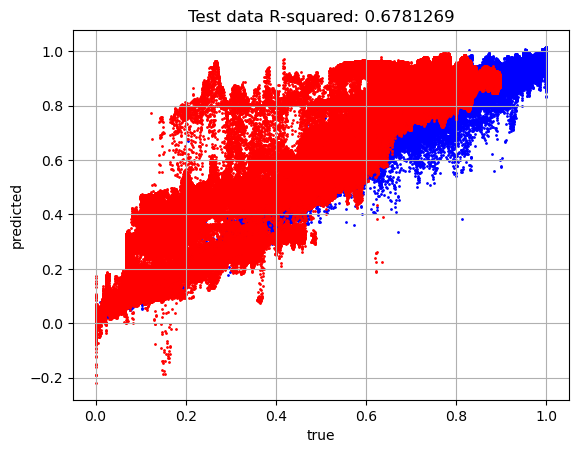

In [16]:
y_train_predictions = loaded_model.predict(X_train)
y_test_predictions = loaded_model.predict(X_test)
r2 = r2_score(y_test_predictions[:,0], y_test[:,0])
r2_train = r2_score(y_train_predictions[:,0], y_train[:,0])
r2_train
plt.grid()
plt.title('Test data R-squared: {:.7f}'.format(r2))
#plt.title(r2)
#plt.title('Test data R-squared')
plt.scatter(y_train[:,0], y_train_predictions[:,0],s=1, c = 'b')
plt.scatter(y_test[:,0], y_test_predictions[:,0],s=1, c = 'r')
plt.xlabel('true')
plt.ylabel('predicted')

In [17]:
r2_train

0.9934144002874346